# 과제
# 꺼삐딴 리와 화수분 소설의 명사, 대명사만으로 빈도가 높은 순위 100개로 워드 클라우드를 그려라

In [30]:
!pip install wordcloud

In [33]:
from kiwipiepy import Kiwi

kiwi = Kiwi()
# tokenize 함수로 형태소 분석 결과를 얻을 수 있습니다.
token = kiwi.tokenize("안녕하세요 형태소 분석기 키위입니다.")

In [34]:
token

[Token(form='안녕', tag='NNG', start=0, len=2),
 Token(form='하', tag='XSA', start=2, len=1),
 Token(form='세', tag='EC', start=3, len=1),
 Token(form='요', tag='JX', start=4, len=1),
 Token(form='형태소', tag='NNG', start=6, len=3),
 Token(form='분석기', tag='NNG', start=10, len=3),
 Token(form='키위', tag='NNG', start=14, len=2),
 Token(form='이', tag='VCP', start=16, len=1),
 Token(form='ᆸ니다', tag='EF', start=16, len=3),
 Token(form='.', tag='SF', start=19, len=1)]

In [35]:
for i in token:
    print("[형태소]", i.form, "[품사표지]", i.tag)

[형태소] 안녕 [품사표지] NNG
[형태소] 하 [품사표지] XSA
[형태소] 세 [품사표지] EC
[형태소] 요 [품사표지] JX
[형태소] 형태소 [품사표지] NNG
[형태소] 분석기 [품사표지] NNG
[형태소] 키위 [품사표지] NNG
[형태소] 이 [품사표지] VCP
[형태소] ᆸ니다 [품사표지] EF
[형태소] . [품사표지] SF


## 과제 2. 소설 2개 워드 클라우드 그리기

In [36]:
# 필요한 라이브러리를 설치
!pip install kiwipiepy wordcloud

# 라이브러리들을 임포트
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from kiwipiepy import Kiwi
from collections import Counter
from google.colab import files

In [37]:
# 폰트 파일 직접 업로드
print("폰트 파일 업로드")

uploaded_font = files.upload()
font_path = list(uploaded_font.keys())[0] # 업로드된 폰트 파일의 이름
print(f"'{font_path}' 폰트가 준비됨")

폰트 파일 업로드


Saving NanumGothic-Regular.ttf to NanumGothic-Regular.ttf
'NanumGothic-Regular.ttf' 폰트가 준비됨


In [38]:
# 2개 소설 파일 업로드
uploaded = files.upload()

# 업로드된 파일 이름을 변수에 저장
file_captain_lee = '꺼삐딴 리(전광용).txt'
file_hwasubun = '화수분(전영택).txt'

print(f"\n'{file_captain_lee}'와 '{file_hwasubun}' 파일이 성공적으로 업로드됨")

Saving 꺼삐딴 리(전광용).txt to 꺼삐딴 리(전광용).txt
Saving 화수분(전영택).txt to 화수분(전영택).txt

'꺼삐딴 리(전광용).txt'와 '화수분(전영택).txt' 파일이 성공적으로 업로드됨


In [40]:
def extract_words(filename, uploaded_data):
    kiwi = Kiwi()
    try:
        text = uploaded_data[filename].decode('utf-8')
        result = kiwi.tokenize(text)
        target_tags = ['NNG', 'NNP', 'NP']
        words = [token.form for token in result if token.tag in target_tags and len(token.form) > 1]
        return ' '.join(words)
    except KeyError:
        print(f"'{filename}' 파일을 찾을 수 없습니다")
        return ""

꺼삐딴 리 (전광용) 워드클라우드


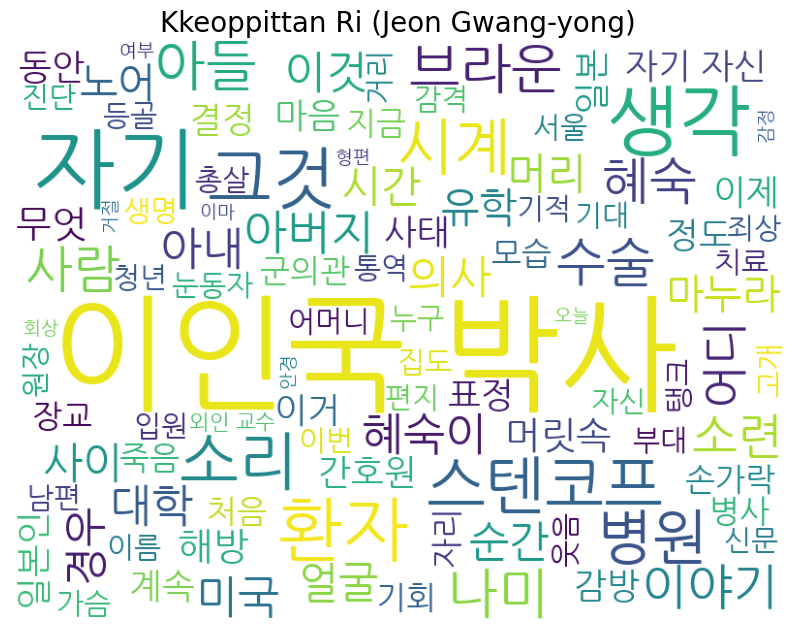

In [41]:
# '꺼삐딴 리' 단어 추출
joined_words_lee = extract_words(file_captain_lee, uploaded)

# 워드클라우드 객체 생성
wc = WordCloud(width=800, height=600, background_color="white",
               max_words=100, font_path=font_path, random_state=0)

# '꺼삐딴 리' 시각화
print("꺼삐딴 리 (전광용) 워드클라우드")
plt.figure(figsize=(10, 8)) # 개별 그래프에 맞는 사이즈로 조정

if joined_words_lee:
    plt.imshow(wc.generate(joined_words_lee))

plt.title('Kkeoppittan Ri (Jeon Gwang-yong)', fontsize=20)
plt.axis("off")
plt.show()

화수분 (전영택) 워드클라우드


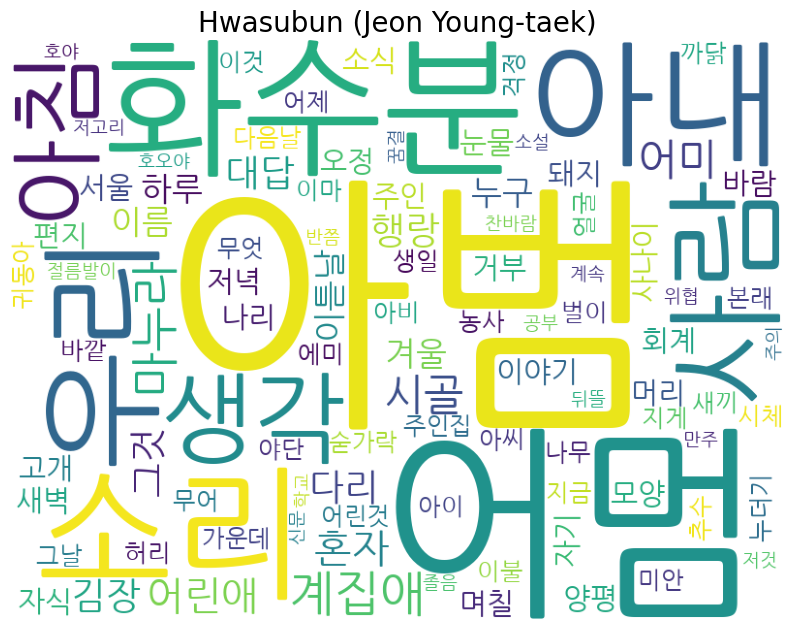

In [42]:
# '화수분' 단어 추출
joined_words_hwasubun = extract_words(file_hwasubun, uploaded)

# 워드클라우드 객체 생성
wc = WordCloud(width=800, height=600, background_color="white",
               max_words=100, font_path=font_path, random_state=0)

# '화수분' 시각화
print("화수분 (전영택) 워드클라우드")
plt.figure(figsize=(10, 8)) # 개별 그래프에 맞는 사이즈로 조정

if joined_words_hwasubun:
    plt.imshow(wc.generate(joined_words_hwasubun))

plt.title('Hwasubun (Jeon Young-taek)', fontsize=20)
plt.axis("off")
plt.show()